In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales = pd.read_csv("D:\AnalytixLabs\Case Studies\Python Case Study\Case Study 4 - Python Visualizations Case Study\SalesData.csv")

In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3709 entries, 0 to 3708
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AccountId           3709 non-null   int64  
 1   AccountName         3709 non-null   object 
 2   Region              3709 non-null   object 
 3   Division            3709 non-null   object 
 4   City                3709 non-null   object 
 5   State               3709 non-null   object 
 6   Tier                3709 non-null   object 
 7   Month               3709 non-null   object 
 8   Sales2015           3709 non-null   float64
 9   Sales2016           3709 non-null   float64
 10  Units2015           3709 non-null   float64
 11  Units2016           3709 non-null   float64
 12  TargetAchevied2015  3709 non-null   float64
 13  TargetAchevied2016  3709 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 405.8+ KB


In [4]:
sales.isnull().sum()

AccountId             0
AccountName           0
Region                0
Division              0
City                  0
State                 0
Tier                  0
Month                 0
Sales2015             0
Sales2016             0
Units2015             0
Units2016             0
TargetAchevied2015    0
TargetAchevied2016    0
dtype: int64

In [5]:
sales.columns

Index(['AccountId', 'AccountName', 'Region', 'Division', 'City', 'State',
       'Tier', 'Month', 'Sales2015', 'Sales2016', 'Units2015', 'Units2016',
       'TargetAchevied2015', 'TargetAchevied2016'],
      dtype='object')

In [6]:
sales_region = sales.groupby('Region')[['Sales2015', 'Sales2016']].sum()

In [7]:
sales_region

,Sales2015,Sales2016
Region,,
Central,7.891729e+06,9.787809e+06
East,9.512916e+06,1.266723e+07
West,5.349745e+06,7.209689e+06


In [8]:
sales

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
0,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Aug,0.00,13208.52,0.0,4.0,0.70,1.53
1,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Oct,10500.78,23114.91,3.0,7.0,0.84,1.31
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3704,7576,Account2736,East,EMPIRE,SYRACUSE,NY,Out,Feb,3684.48,0.00,1.0,0.0,1.06,1.14
3705,4969,Account2740,Central,SOUTHERN STAR,MONTGOMERY,AL,Med,Aug,3684.48,0.00,1.0,0.0,0.96,1.11
3706,2850,Account2746,East,SYNERGY,ASHEVILLE,NC,High,Nov,5067.70,0.00,2.0,0.0,1.11,1.55
3707,1102265,Account2748,West,DIAMONDBACK,SCOTTSDALE,AZ,Out,Jan,3684.48,0.00,1.0,0.0,1.31,1.48


In [9]:
sales_long = sales_region.stack().reset_index()

In [10]:
sales_long

,Region,level_1,0
0,Central,Sales2015,7.891729e+06
1,Central,Sales2016,9.787809e+06
2,East,Sales2015,9.512916e+06
3,East,Sales2016,1.266723e+07
4,West,Sales2015,5.349745e+06
5,West,Sales2016,7.209689e+06


In [11]:
sales_long.columns = ['Region', 'Year', 'Sales']

In [12]:
sales_long

,Region,Year,Sales
0,Central,Sales2015,7.891729e+06
1,Central,Sales2016,9.787809e+06
2,East,Sales2015,9.512916e+06
3,East,Sales2016,1.266723e+07
4,West,Sales2015,5.349745e+06
5,West,Sales2016,7.209689e+06


In [13]:
sales_long['Year'] = sales_long['Year'].str.replace('Sales', '')

In [14]:
sales_long  

,Region,Year,Sales
0,Central,2015,7.891729e+06
1,Central,2016,9.787809e+06
2,East,2015,9.512916e+06
3,East,2016,1.266723e+07
4,West,2015,5.349745e+06
5,West,2016,7.209689e+06


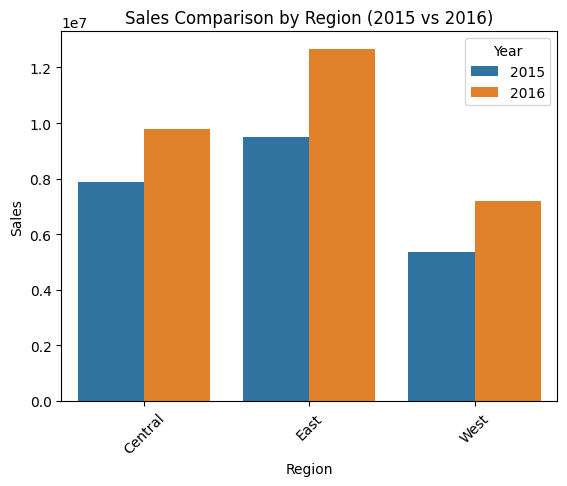

In [15]:
sns.barplot(data=sales_long, x='Region', y='Sales', hue='Year')
plt.title("Sales Comparison by Region (2015 vs 2016)")
plt.xticks(rotation=45)
plt.show()

In [16]:
# contributing factors to the sales for each region in 2016.

In [17]:
sales_2016 = sales.groupby('Region')['Sales2016'].sum()

In [18]:
sales_2016

Region
Central    9.787809e+06
East       1.266723e+07
West       7.209689e+06
Name: Sales2016, dtype: float64

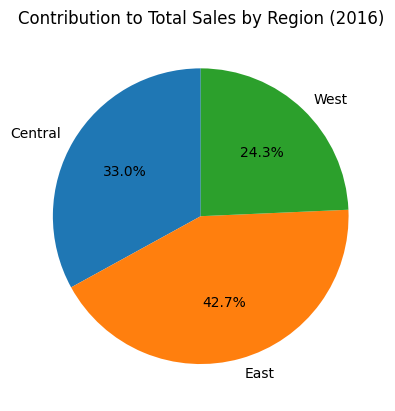

In [19]:
plt.pie(sales_2016,
        labels= sales_2016.index,
        autopct = '%1.1f%%',
        startangle=90)
plt.title("Contribution to Total Sales by Region (2016)")
plt.show()

In [20]:
# Compare the total sales of 2015 and 2016 with respect to Region and Tiers

In [21]:
sales_rt = sales.groupby(['Region', 'Tier'])[['Sales2015', 'Sales2016']].sum()

In [22]:
sales_rt = sales_rt.reset_index()

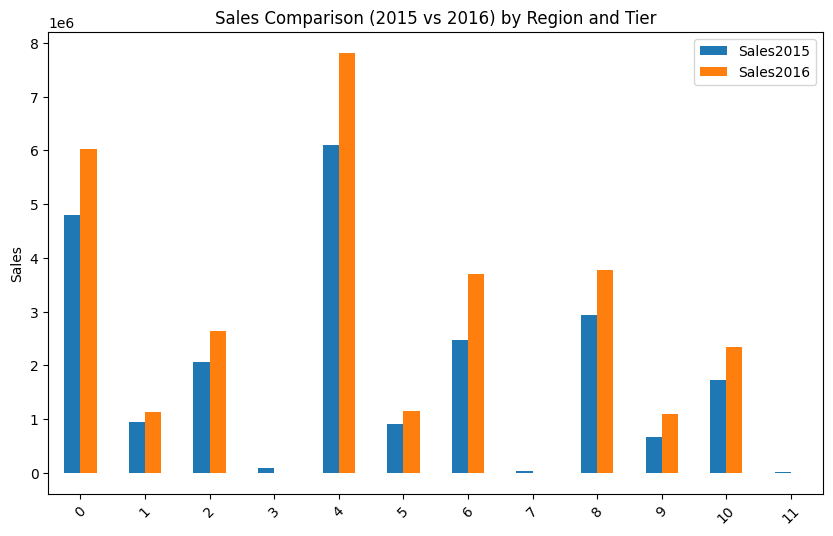

In [23]:
sales_rt.plot(kind='bar', figsize=(10,6))

plt.title("Sales Comparison (2015 vs 2016) by Region and Tier")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
east_sales = sales[sales['Region'] == 'East']

In [25]:
east_sales

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53
5,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Jul,0.00,10525.24,0.0,4.0,1.03,1.45
6,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Feb,2631.31,42812.62,1.0,17.0,1.08,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,7239,Account2716,East,MINUTEMEN,BOSTON N,MA,High,Dec,3128.34,3128.34,1.0,1.0,1.08,1.10
3695,7920,Account2725,East,ORION,SAINT PETERSBURG,FL,Med,Nov,0.00,16163.05,0.0,5.0,0.77,1.18
3700,1174604,Account2733,East,BIG APPLE,BROOKLYN,NY,Out,May,7368.96,0.00,2.0,0.0,1.34,1.04
3704,7576,Account2736,East,EMPIRE,SYRACUSE,NY,Out,Feb,3684.48,0.00,1.0,0.0,1.06,1.14


In [26]:
state_sales = east_sales.groupby('State')[['Sales2015', 'Sales2016']].sum()

In [27]:
state_sales

,Sales2015,Sales2016
State,,
CT,197202.790,323502.31
DC,216723.950,257421.69
FL,1660162.000,2508232.28
GA,681546.460,946919.77
MA,419278.750,687096.45
MD,527309.060,750008.79
ME,77425.640,183673.05
NC,1292801.640,1610521.00
NH,136419.380,144717.51


In [28]:
decline_states = state_sales[state_sales['Sales2016'] < state_sales['Sales2015']]

In [29]:
decline_states

,Sales2015,Sales2016
State,,
NY,1725415.065,1703135.8


In [30]:
# In all the High tier, which Division saw a decline in number of units sold in 2016 compared to 2015

In [31]:
high_sales = sales[sales['Tier'] == 'High']

In [32]:
high_sales

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016
5,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Jul,0.00,10525.24,0.0000,4.0,1.03,1.45
6,2400,Account4,East,MINUTEMEN,PORTLAND,ME,High,Feb,2631.31,42812.62,1.0000,17.0,1.08,0.99
9,2408,Account7,East,BIG APPLE,JERSEY CITY,NJ,High,Aug,0.00,10994.54,0.0000,4.0,1.11,1.54
10,2408,Account7,East,BIG APPLE,JERSEY CITY,NJ,High,Feb,9640.17,27316.66,3.0000,10.0,1.06,1.08
17,2426,Account13,East,BIG APPLE,PATERSON,NJ,High,Oct,0.00,3128.34,0.0000,1.0,1.42,1.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3699,3048,Account2731,Central,RACEWAY,OWENSBORO,KY,High,Mar,9890.91,0.00,4.0000,0.0,0.79,1.39
3701,7076,Account2735,Central,WRANGLER,HOUSTON S,TX,High,Nov,-11053.44,0.00,-3.0000,0.0,0.92,1.26
3702,7076,Account2735,Central,WRANGLER,HOUSTON S,TX,High,Jul,3919.19,0.00,1.0000,0.0,1.08,1.42
3703,7076,Account2735,Central,WRANGLER,HOUSTON S,TX,High,Oct,22575.87,0.00,5.9999,0.0,1.03,1.13


In [33]:
division_units = high_sales.groupby('Division')[['Units2015', 'Units2016']].sum()

In [34]:
division_units

,Units2015,Units2016
Division,,
BIG APPLE,180.8330,231.0000
CHARGERS,123.6666,164.4999
CONGRESSIONAL,164.5003,205.0000
DIAMONDBACK,153.3334,176.6667
EMPIRE,414.3332,449.3332
GRIDIRON,213.6673,246.1675
GULF STREAM,185.0000,301.0009
HAILSTORM,187.8338,247.0003
KINETIC,214.3334,244.5001


In [35]:
decline_units = division_units[division_units['Units2016'] < division_units['Units2015']]

In [36]:
decline_units

,Units2015,Units2016
Division,,


In [37]:
# Quarters

In [38]:
sales['Month']

0       Aug
1       Oct
2       Jun
3       Mar
4       Sep
       ... 
3704    Feb
3705    Aug
3706    Nov
3707    Jan
3708    Jun
Name: Month, Length: 3709, dtype: object

In [39]:
sales['Qtr'] = np.where(sales['Month'].isin(['Jan',"Feb",'Mar']), 'Q1',
                        np.where(sales['Month'].isin(['Apr','May',"Jun"]), 'Q2',
                                 np.where(sales['Month'].isin(['Jul','Aug','Sep']), 'Q3', 'Q4')))

In [40]:
sales

,AccountId,AccountName,Region,Division,City,State,Tier,Month,Sales2015,Sales2016,Units2015,Units2016,TargetAchevied2015,TargetAchevied2016,Qtr
0,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Aug,0.00,13208.52,0.0,4.0,0.70,1.53,Q3
1,1116,Account1,West,DIAMONDBACK,PHOENIX W,AZ,Low,Oct,10500.78,23114.91,3.0,7.0,0.84,1.31,Q4
2,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Jun,0.00,6627.00,0.0,3.0,1.15,1.29,Q2
3,2391,Account2,East,MINUTEMEN,HARTFORD,CT,Med,Mar,19881.00,13254.00,9.0,6.0,1.33,1.17,Q1
4,2397,Account3,East,MINUTEMEN,WORCESTER,MA,Med,Sep,3684.48,0.00,1.0,0.0,1.02,1.53,Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3704,7576,Account2736,East,EMPIRE,SYRACUSE,NY,Out,Feb,3684.48,0.00,1.0,0.0,1.06,1.14,Q1
3705,4969,Account2740,Central,SOUTHERN STAR,MONTGOMERY,AL,Med,Aug,3684.48,0.00,1.0,0.0,0.96,1.11,Q3
3706,2850,Account2746,East,SYNERGY,ASHEVILLE,NC,High,Nov,5067.70,0.00,2.0,0.0,1.11,1.55,Q4
3707,1102265,Account2748,West,DIAMONDBACK,SCOTTSDALE,AZ,Out,Jan,3684.48,0.00,1.0,0.0,1.31,1.48,Q1


In [41]:
# Compare Qtr wise sales in 2015 and 2016 in a bar plot



In [42]:
qtr_sales = sales.groupby('Qtr')[['Sales2015', 'Sales2016']].sum()

In [43]:
qtr_sales

,Sales2015,Sales2016
Qtr,,
Q1,5.485800e+06,6.997953e+06
Q2,5.390862e+06,7.237361e+06
Q3,6.164094e+06,7.861546e+06
Q4,5.713634e+06,7.567868e+06


In [44]:
qtr_sales = qtr_sales.reindex(['Q1','Q2','Q3','Q4'])

In [45]:
qtr_sales

,Sales2015,Sales2016
Qtr,,
Q1,5.485800e+06,6.997953e+06
Q2,5.390862e+06,7.237361e+06
Q3,6.164094e+06,7.861546e+06
Q4,5.713634e+06,7.567868e+06


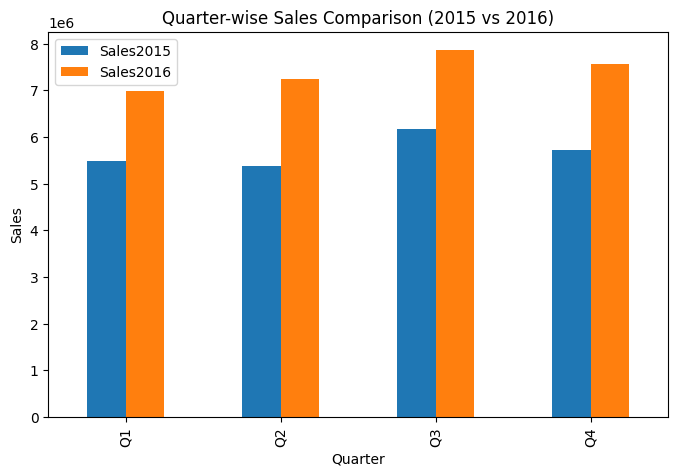

In [59]:
qtr_sales.plot(kind='bar', figsize = (8,5))

plt.title("Quarter-wise Sales Comparison (2015 vs 2016)")
plt.xlabel("Quarter")
plt.ylabel("Sales")


plt.show()

In [60]:
# Determine the composition of Qtr wise sales in and 2016 with regards to all the Tiers in a pie chart.

In [65]:
qtr_tier_sales = sales.groupby(['Qtr', 'Tier'])['Sales2016'].sum()

In [68]:
qtr_tier_sales

Qtr  Tier
Q1   High    3.867719e+06
     Low     9.488328e+05
     Med     2.181402e+06
     Out     0.000000e+00
Q2   High    4.130953e+06
     Low     8.905948e+05
     Med     2.215814e+06
     Out     0.000000e+00
Q3   High    4.872559e+06
     Low     7.951777e+05
     Med     2.197058e+06
     Out    -3.248530e+03
Q4   High    4.740002e+06
     Low     7.426594e+05
     Med     2.085207e+06
     Out     0.000000e+00
Name: Sales2016, dtype: float64

In [69]:
qtr_tier_pivot = qtr_tier_sales.unstack()

In [70]:
qtr_tier_pivot

Tier,High,Low,Med,Out
Qtr,,,,
Q1,3867718.595,948832.77,2.181402e+06,0.00
Q2,4130952.560,890594.75,2.215814e+06,0.00
Q3,4872559.250,795177.71,2.197058e+06,-3248.53
Q4,4740001.985,742659.39,2.085207e+06,0.00


In [74]:
qtr_tier_pivot = qtr_tier_pivot.drop(columns='Out')

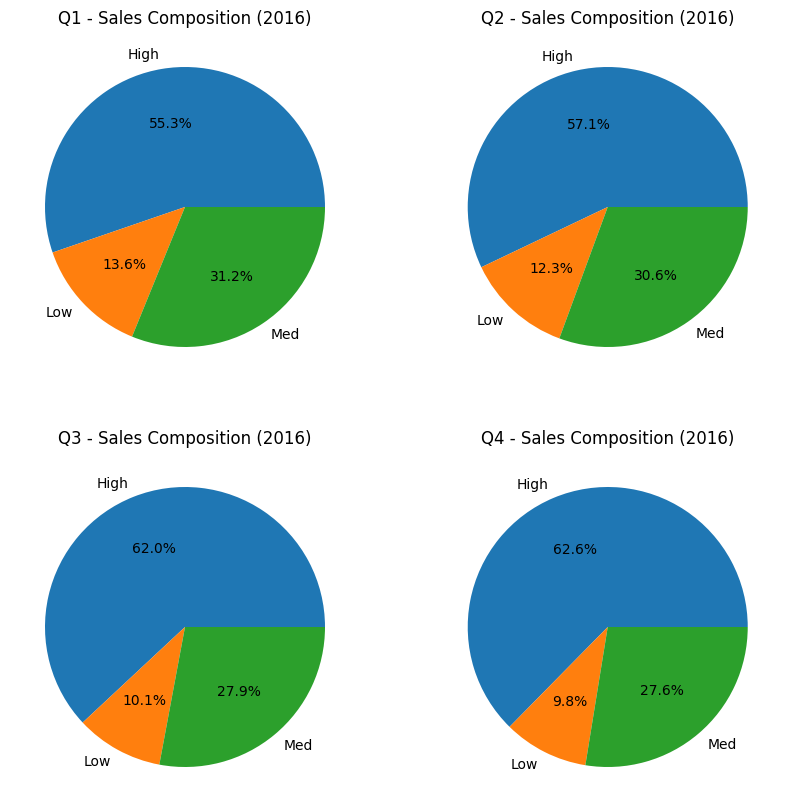

In [75]:
plt.figure(figsize=(10,10))

quarters = ['Q1','Q2','Q3','Q4']

for i, q in enumerate(quarters, 1):
    plt.subplot(2,2,i)
    plt.pie(
        qtr_tier_pivot.loc[q],
        labels = qtr_tier_pivot.columns,
        autopct='%1.1f%%'
    )
    plt.title(f"{q} - Sales Composition (2016)")